# Analysis of a CFIS shear catalogue
First steps.

In [1]:
import numpy as np

from astropy.io import fits
import matplotlib.pylab as plt

import treecorr

%matplotlib inline

## Open FITS file

In [2]:
cat_name = 'shape_cat_cor_alpha.fits'
hdu = fits.open(cat_name)
data = hdu[1].data

In [3]:
# Print column names
data.dtype.names

('RA',
 'Dec',
 'e1',
 'e2',
 'w',
 'mag',
 'snr',
 'e1_uncal',
 'e2_uncal',
 'R_g11',
 'R_g22',
 'R_g12',
 'R_g21',
 'e1_PSF',
 'e2_PSF',
 'fwhm_PSF',
 'mask_extern',
 'patch',
 'e1_cor',
 'e2_cor')

In [4]:
# Print header
hdu[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  154 / length of dimension 1                          
NAXIS2  =             97239250 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   20 / number of table fields                         
TTYPE1  = 'RA      '                                                            
TFORM1  = 'D       '                                                            
TTYPE2  = 'Dec     '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'e1      '        

## Plot spatial distribution

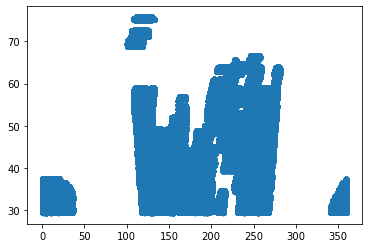

In [5]:
_ = plt.plot(data['ra'], data['dec'], '.')

## Compute shear-shear correlation

In [6]:
# Create TreeCorr configuration

sep_units = 'arcmin'

TreeCorrConfig = {
        'ra_units': 'degrees',
        'dec_units': 'degrees',
        'max_sep': '200',
        'min_sep': '0.1',
        'sep_units': sep_units,
        'nbins': 20
    }

In [7]:
# Create TreeCorr catalogue

cat_gal = treecorr.Catalog(
    ra=data['RA'],
    dec=data['Dec'],
    g1=data['e1'],
    g2=data['e2'],
    w=data['w'],
    ra_units='degrees',
    dec_units='degrees'
)

In [8]:
# Create and process correlation object

gg = treecorr.GGCorrelation(TreeCorrConfig)

gg.process(cat_gal, cat_gal)

In [ ]:
gg.write('cs.txt', file_type='ASCII')

## Plot shear correlation functions.
Error bars are computed by treecorr, and are here shape/shot noise only.

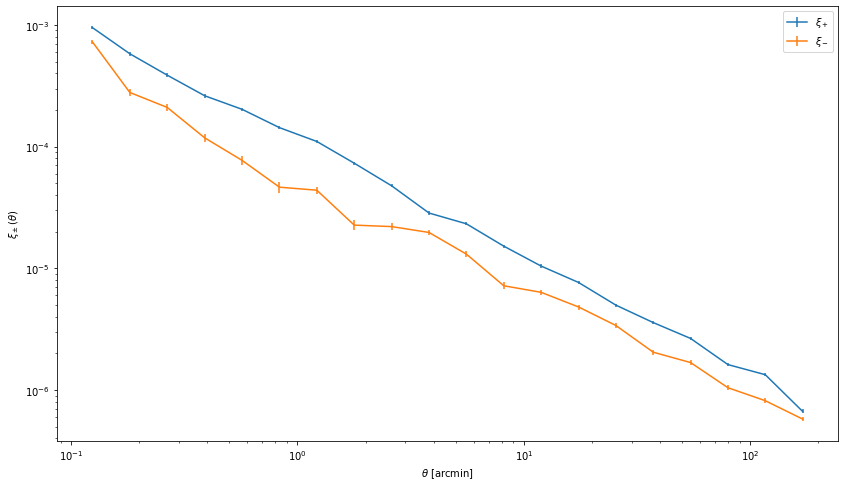

In [10]:
plt.figure(figsize=(14,8))

plt.errorbar(gg.meanr, gg.xip, yerr=np.sqrt(gg.varxip), label=r'$\xi_+$')
plt.errorbar(gg.meanr, gg.xim, yerr=np.sqrt(gg.varxim), label=r'$\xi_-$')
plt.loglog()

plt.legend()
plt.xlabel(rf'$\theta$ [{sep_units}]')
_ = plt.ylabel(r'$\xi_\pm(\theta)$')
plt.savefig('cs.pdf')

In [11]:
cat_gal_cor = treecorr.Catalog(
    ra=data['RA'],
    dec=data['Dec'],
    g1=data['e1_cor'],
    g2=data['e2_cor'],
    w=data['w'],
    ra_units='degrees',
    dec_units='degrees'
)

In [ ]:
gg_cor = treecorr.GGCorrelation(TreeCorrConfig)

gg_cor.process(cat_gal_cor, cat_gal_cor)

In [ ]:
gg_cor.write('cs_cor.txt', file_type='ASCII')

In [ ]:
plt.figure(figsize=(14,8))

plt.errorbar(gg.meanr, gg.xip, yerr=np.sqrt(gg.varxip), label=r'$\xi_+$')
plt.errorbar(gg.meanr, gg.xim, yerr=np.sqrt(gg.varxim), label=r'$\xi_-$')

plt.errorbar(gg_cor.meanr, gg_cor.xip, yerr=np.sqrt(gg_cor.varxip), label=r'$\xi_+$ cor')
plt.errorbar(gg_cor.meanr, gg_cor.xim, yerr=np.sqrt(gg_cor.varxim), label=r'$\xi_-$ cor')

plt.loglog()

plt.legend()
plt.xlabel(rf'$\theta$ [{sep_units}]')
_ = plt.ylabel(r'$\xi_\pm(\theta)$')
plt.savefig('cs+cor.pdf')